In [1]:
import xarray as xr
import geopandas as gpd
import rioxarray
import glob
import numpy as np

# --------------------------------------------
# Step 1: Load basin shapefile
# --------------------------------------------
basin_shp = "C:/Study area/Upper_Ravi_sub-basin/Upper_Ravi_sub-basin.shp"
basin = gpd.read_file(basin_shp)
basin = basin.to_crs("EPSG:4326")  # Ensure CRS matches raster

# --------------------------------------------
# Step 2: Load NetCDF files
# --------------------------------------------
imd_files = sorted(glob.glob("C:/Rainfall_NetCDF/*.nc"))    # IMD yearly NetCDFs
nex_files = sorted(glob.glob("C:/Climate data/EC_EARTH3/*.nc"))    # NEX yearly NetCDFs

imd = xr.open_mfdataset(imd_files, combine='by_coords')
nex = xr.open_mfdataset(nex_files, combine='by_coords')



In [2]:
# Step 3: Prepare variables
# --------------------------------------------
imd_var = imd['RAINFALL'].rename({"TIME":"time","LATITUDE":"lat","LONGITUDE":"lon"})
imd_var = imd_var.rio.write_crs("EPSG:4326")

nex_var = nex['pr'] * 86400  # Convert from m/s → mm/day
nex_var = nex_var.rename({"time":"time","lat":"lat","lon":"lon"})
nex_var = nex_var.rio.write_crs("EPSG:4326")


In [3]:
# Step 4: Get basin bounds + buffer
# --------------------------------------------
buffer_deg = 0.5  # Small buffer to ensure overlap (~2 NEX cells)
minx, miny, maxx, maxy = basin.total_bounds
subset_box = [minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg]


In [4]:
# Step 5: Subset NEX regionally (handle lat ordering)
# --------------------------------------------
# Latitude
if nex_var.lat.values[0] > nex_var.lat.values[-1]:
    lat_slice = slice(subset_box[3], subset_box[1])  # descending
else:
    lat_slice = slice(subset_box[1], subset_box[3])  # ascending

# Longitude (0-360° handled automatically)
nex_clip = nex_var.sel(
    lon=slice(subset_box[0], subset_box[2]),
    lat=lat_slice
)


In [5]:
# Step 6: Regrid NEX → IMD grid
# --------------------------------------------
nex_regridded = nex_clip.interp(
    lat=imd_var.lat,
    lon=imd_var.lon,
    method="linear"
)


In [6]:
# Step 7: Clip both datasets to basin
# --------------------------------------------
imd_clip = imd_var.rio.clip(list(basin.geometry), basin.crs, drop=True)
nex_clip = nex_regridded.rio.clip(list(basin.geometry), basin.crs, drop=True)


In [7]:
def check_spatial_grid(ds, name="Dataset"):
    print(f"--- {name} ---")
    print("Shape:", ds.shape)
    
    if 'lat' in ds.coords and 'lon' in ds.coords:
        print("Number of lat points:", len(ds.lat))
        print("Number of lon points:", len(ds.lon))
        print("Lat values:", ds.lat.values)
        print("Lon values:", ds.lon.values)
    else:
        print("No lat/lon coordinates found!")

    # Count valid (non-NaN) grid cells per time step
    import numpy as np
    valid_cells = np.isfinite(ds.values).sum(axis=(1,2))  # sum over lat/lon
    print("Number of valid grid cells per time step (first 5):", valid_cells[:5])
    print("\n")

# Check IMD
check_spatial_grid(imd_clip, name="IMD Clip")

# Check NEX
check_spatial_grid(nex_clip, name="NEX Clip")


--- IMD Clip ---
Shape: (10957, 3, 6)
Number of lat points: 3
Number of lon points: 6
Lat values: [32.25 32.5  32.75]
Lon values: [75.75 76.   76.25 76.5  76.75 77.  ]
Number of valid grid cells per time step (first 5): [9 9 9 9 9]


--- NEX Clip ---
Shape: (10957, 3, 6)
Number of lat points: 3
Number of lon points: 6
Lat values: [32.25 32.5  32.75]
Lon values: [75.75 76.   76.25 76.5  76.75 77.  ]
Number of valid grid cells per time step (first 5): [9 9 9 9 9]




In [7]:
print("Clipped dataset shape:", imd_clip.shape)
print("Latitude length:", len(imd_clip.lat))
print("Longitude length:", len(imd_clip.lon))


Clipped dataset shape: (10957, 3, 6)
Latitude length: 3
Longitude length: 6


In [8]:
print("Clipped dataset shape:", nex_clip.shape)
print("Latitude length:", len(nex_clip.lat))
print("Longitude length:", len(nex_clip.lon))


Clipped dataset shape: (10957, 3, 6)
Latitude length: 3
Longitude length: 6


In [9]:
import pandas as pd
import cftime
import pandas as pd


# ===========================================
# STEP A: Normalize time coordinates
# ===========================================

# Convert to pandas datetime (ensures same dtype)
imd_clip['time'] = pd.to_datetime(imd_clip['time'].values)
nex_clip['time'] = pd.to_datetime(nex_clip['time'].values)

# Floor both to daily timestamps (remove hours/minutes)
imd_clip['time'] = imd_clip['time'].dt.floor('D')
nex_clip['time'] = nex_clip['time'].dt.floor('D')

# ===========================================
# STEP B: Ensure both cover same daily range
# ===========================================
common_start = max(imd_clip.time.min(), nex_clip.time.min())
common_end   = min(imd_clip.time.max(), nex_clip.time.max())

imd_clip = imd_clip.sel(time=slice(common_start, common_end))
nex_clip = nex_clip.sel(time=slice(common_start, common_end))


In [10]:
print("IMD shape:", imd_clip.shape)
print("NEX shape:", nex_clip.shape)


IMD shape: (10957, 3, 6)
NEX shape: (10957, 3, 6)


In [11]:
# STEP 2: Define Quantile Mapping Function
# ===========================================
def quantile_mapping(obs, sim):
    """
    Empirical quantile mapping for 1D arrays.
    Returns array with same length as sim, keeping NaNs for invalid points.
    """
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs_valid, sim_valid = obs[mask], sim[mask]

    # Prepare full-length result
    result = np.full_like(sim, np.nan)

    # Only apply correction if enough valid points
    if len(obs_valid) >= 30:
        sim_sorted, sim_q = np.sort(sim_valid), np.linspace(0, 1, len(sim_valid))
        obs_sorted = np.sort(obs_valid)
        sim_ranks = stats.rankdata(sim_valid, method='average') / len(sim_valid)
        corrected = np.interp(sim_ranks, sim_q, obs_sorted)
        result[mask] = corrected  # only replace valid points

    # If <30 valid points, result stays NaN
    return result



In [12]:
# STEP 3: Apply Grid-to-Grid Bias Correction
# ===========================================
import numpy as np
from scipy import stats


corrected_values = np.empty_like(nex_clip.values)

for i in range(nex_clip.shape[1]):   # latitude index
    for j in range(nex_clip.shape[2]):  # longitude index
        obs_series = imd_clip[:, i, j].values
        sim_series = nex_clip[:, i, j].values
        corrected_values[:, i, j] = quantile_mapping(obs_series, sim_series)


In [13]:
# STEP 4: Store Corrected Data as xarray
# ===========================================
nex_corrected = xr.DataArray(
    data=corrected_values,
    dims=nex_clip.dims,
    coords=nex_clip.coords,
    name='pr_corrected',
    attrs=nex_clip.attrs
)

## Load & preprocess future SSP545 rainfall

In [16]:
# ===========================================
# FUTURE SSP545: Load, regrid, clip
# ===========================================
import xarray as xr
import glob

# Path for future SSP545 data (yearly NetCDFs)
ssp545_files = sorted(glob.glob("C:/Climate data/EC-EARTH3 Future/SSP 585/*.nc"))

ssp545_ds = xr.open_mfdataset(ssp545_files, combine='by_coords')

# Convert pr (m/s) → mm/day, rename like before
ssp545_var = ssp545_ds['pr'] * 86400.0
ssp545_var = ssp545_var.rename({"time": "time", "lat": "lat", "lon": "lon"})
ssp545_var = ssp545_var.rio.write_crs("EPSG:4326")

# ---- Spatial subset using same subset_box and lat_slice logic ----
# (reuse subset_box and lat_slice calculation from your script)

if ssp545_var.lat.values[0] > ssp545_var.lat.values[-1]:
    lat_slice_future = slice(subset_box[3], subset_box[1])  # descending
else:
    lat_slice_future = slice(subset_box[1], subset_box[3])  # ascending

ssp545_subset = ssp545_var.sel(
    lon=slice(subset_box[0], subset_box[2]),
    lat=lat_slice_future
)

# ---- Regrid SSP545 to IMD grid (same as you did for historical NEX) ----
ssp545_regridded = ssp545_subset.interp(
    lat=imd_var.lat,
    lon=imd_var.lon,
    method="linear"
)

# ---- Clip to basin ----
ssp545_clip = ssp545_regridded.rio.clip(list(basin.geometry), basin.crs, drop=True)

# ---- Make sure time is clean daily datetime ----
ssp545_clip['time'] = pd.to_datetime(ssp545_clip['time'].values)
ssp545_clip['time'] = ssp545_clip['time'].dt.floor('D')


# Redefine quantile mapping in two steps: fit + apply

In [17]:
import numpy as np

def compute_qm_params(obs_hist, sim_hist, min_points=30):
    """
    Fit empirical quantile mapping parameters using historical data.
    Returns (sim_sorted, obs_sorted, q) or None if too few points.
    """
    mask = np.isfinite(obs_hist) & np.isfinite(sim_hist)
    obs_valid = obs_hist[mask]
    sim_valid = sim_hist[mask]

    if len(obs_valid) < min_points:
        return None  # not enough data → leave as NaN later

    # Sort and define quantiles for the historical sim
    sim_sorted = np.sort(sim_valid)
    obs_sorted = np.sort(obs_valid)
    q = np.linspace(0, 1, len(sim_sorted))

    return sim_sorted, obs_sorted, q


def apply_qm_to_series(sim_series, params):
    """
    Apply pre-computed QM parameters to a 1D series (future sim).
    """
    result = np.full_like(sim_series, np.nan, dtype=float)
    if params is None:
        return result

    sim_sorted, obs_sorted, q = params

    mask = np.isfinite(sim_series)
    if mask.sum() == 0:
        return result

    # Step 1: find percentile of future value in historical sim CDF
    # p in [0,1] for each value
    p = np.interp(sim_series[mask], sim_sorted, q, left=0.0, right=1.0)

    # Step 2: map percentile to obs distribution
    result[mask] = np.interp(p, q, obs_sorted)

    return result


## Apply mapping: historical IMD+NEX → future SSP545

In [18]:
# ===========================================
# APPLY QM TO FUTURE SSP545
# ===========================================

time_fut = ssp545_clip.shape[0]
nlat = ssp545_clip.shape[1]
nlon = ssp545_clip.shape[2]

ssp545_corrected_values = np.full_like(ssp545_clip.values, np.nan, dtype=float)

for i in range(nlat):
    for j in range(nlon):
        # Historical obs and sim at this grid cell
        obs_hist = imd_clip[:, i, j].values  # IMD
        sim_hist = nex_clip[:, i, j].values  # historical NEX

        # Future sim series (SSP545)
        sim_future = ssp545_clip[:, i, j].values

        # 1) Fit QM params from historical data
        params = compute_qm_params(obs_hist, sim_hist, min_points=30)

        # 2) Apply to future series
        ssp545_corrected_values[:, i, j] = apply_qm_to_series(sim_future, params)

# Wrap as xarray DataArray
ssp545_corrected = xr.DataArray(
    data=ssp545_corrected_values,
    dims=ssp545_clip.dims,
    coords=ssp545_clip.coords,
    name='pr_corrected_ssp545',
    attrs=ssp545_clip.attrs
)


## Define the three time periods

In [19]:
periods = {
    "2040": slice("2015-01-01", "2044-12-31"),  # Near future
    "2070": slice("2045-01-01", "2074-12-31"),  # Mid future
    "2100": slice("2071-01-01", "2100-12-31"),  # Far future
}


## Function to compute Mean Annual, RX1day, RX3day for one period

In [20]:
import xarray as xr
import numpy as np

def compute_indices_for_period(da, time_slice):
    """
    da: daily precip (mm/day), dims: time, lat, lon
    time_slice: e.g. slice("2015-01-01", "2044-12-31")
    returns dict with DataArrays: mean_annual, rx1day, rx3day
    """
    sub = da.sel(time=time_slice)

    # ---- Mean Annual Precipitation (mm/year) ----
    # annual total (sum of daily), then mean over all years in the period
    annual_sum = sub.groupby("time.year").sum("time")       # (year, lat, lon)
    mean_annual = annual_sum.mean("year")                   # (lat, lon)

    # ---- RX1day: annual maximum 1-day precipitation ----
    rx1day_year = sub.groupby("time.year").max("time")      # (year, lat, lon)
    rx1day = rx1day_year.mean("year")                       # (lat, lon)

    # ---- RX3day: annual maximum 3-day running sum ----
    # rolling 3-day window, sum, then annual max, then mean over years
    rolling3 = sub.rolling(time=3, min_periods=3).sum()     # (time, lat, lon)
    rx3_year = rolling3.groupby("time.year").max("time")    # (year, lat, lon)
    rx3day = rx3_year.mean("year")                          # (lat, lon)

    return {
        "mean_annual": mean_annual,
        "rx1day": rx1day,
        "rx3day": rx3day,
    }


In [21]:
indices_2040 = compute_indices_for_period(ssp545_corrected, periods["2040"])
indices_2070 = compute_indices_for_period(ssp545_corrected, periods["2070"])
indices_2100 = compute_indices_for_period(ssp545_corrected, periods["2100"])


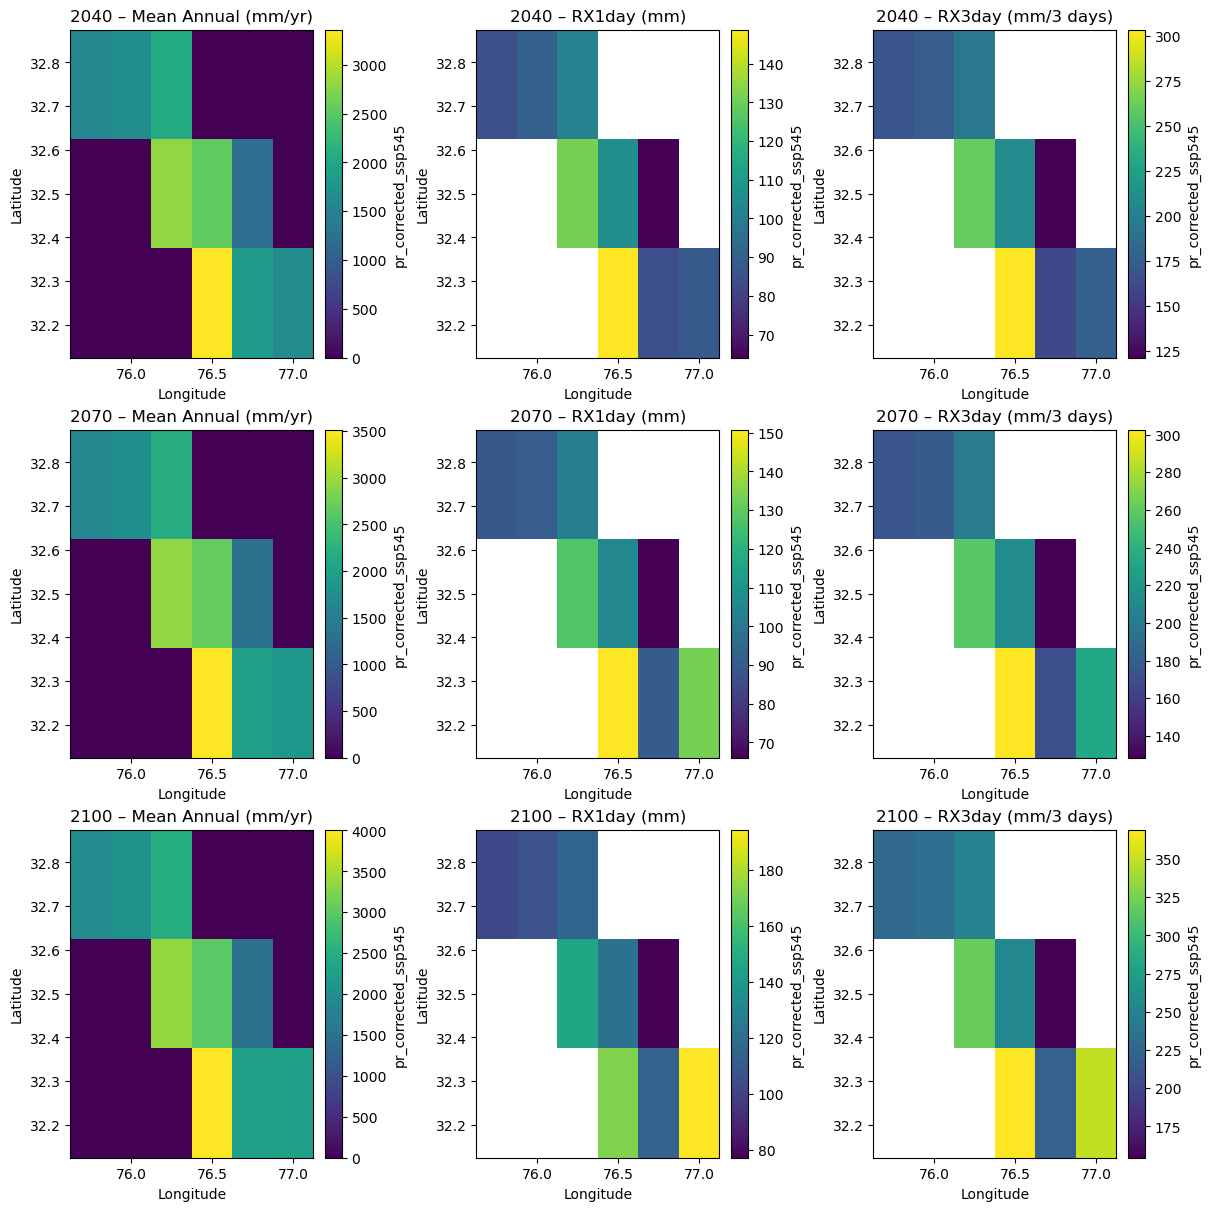

In [22]:
import matplotlib.pyplot as plt

period_labels = ["2040", "2070", "2100"]
all_indices = {
    "2040": indices_2040,
    "2070": indices_2070,
    "2100": indices_2100,
}

index_names = ["mean_annual", "rx1day", "rx3day"]
index_titles = ["Mean Annual (mm/yr)", "RX1day (mm)", "RX3day (mm/3 days)"]

fig, axes = plt.subplots(
    nrows=3, ncols=3, figsize=(12, 12),
    constrained_layout=True
)

for i, per in enumerate(period_labels):
    for j, (idx_key, idx_title) in enumerate(zip(index_names, index_titles)):
        ax = axes[i, j]
        da = all_indices[per][idx_key]

        # xarray plot (lat, lon)
        im = da.plot(ax=ax, add_colorbar=True)

        ax.set_title(f"{per} – {idx_title}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.show()


## Organize them in a dict

In [23]:
all_indices = {
    "2040": indices_2040,
    "2070": indices_2070,
    "2100": indices_2100,
}
index_names = ["mean_annual", "rx1day", "rx3day"]


## Save each index as GeoTIFF

In [24]:
import os

# Choose output directory
out_dir = r"C:/Climate data/EC-EARTH3 Future"
os.makedirs(out_dir, exist_ok=True)

# Combine your period-wise index dictionaries
all_indices = {
    "2040": indices_2040,
    "2070": indices_2070,
    "2100": indices_2100,
}

# Define the scenario name you’re saving
scenario = "ssp585"   # change to "ssp585" if needed

# Define mapping of variable names to output labels
index_labels = {
    "mean_annual": "mean",
    "rx1day": "RX1day",
    "rx3day": "RX3day"
}

# Save each raster
for period, inds in all_indices.items():
    for var_key, var_label in index_labels.items():
        da = inds[var_key]

        # Ensure CRS exists (optional if already set)
        # da = da.rio.write_crs("EPSG:4326", inplace=True)

        # Construct clean file name
        filename = f"{scenario}_{var_label}_{period}.tif"
        out_path = os.path.join(out_dir, filename)

        # Save to GeoTIFF
        da.rio.to_raster(out_path)
        print("✅ Saved:", out_path)


✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_mean_2040.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_RX1day_2040.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_RX3day_2040.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_mean_2070.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_RX1day_2070.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_RX3day_2070.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_mean_2100.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_RX1day_2100.tif
✅ Saved: C:/Climate data/EC-EARTH3 Future\ssp585_RX3day_2100.tif
